In [1]:
import nltk

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('treebank')

[nltk_data] Downloading package punkt to /home/ariel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/ariel/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package treebank to /home/ariel/nltk_data...
[nltk_data]   Package treebank is already up-to-date!


True

In [2]:
import pandas as pd

df = pd.read_csv("dataset/tweetsDisaster/train.csv")

print(df.head())

   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [4]:
df.dropna(inplace=True)
df.drop(columns=["id"], inplace=True)

In [5]:
print(df.count())

keyword     5080
location    5080
text        5080
target      5080
dtype: int64


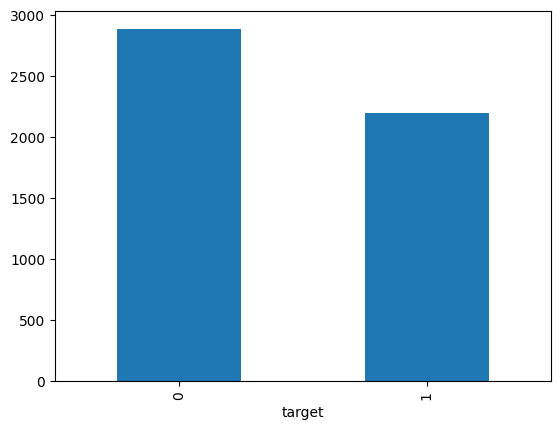

In [6]:
import matplotlib.pyplot as plt

df['target'].value_counts().plot(kind='bar')
plt.show()

In [7]:
df['text_length'] = df['text'].apply(len)
df.groupby('target')['text_length'].mean()

target
0     97.607836
1    108.508197
Name: text_length, dtype: float64

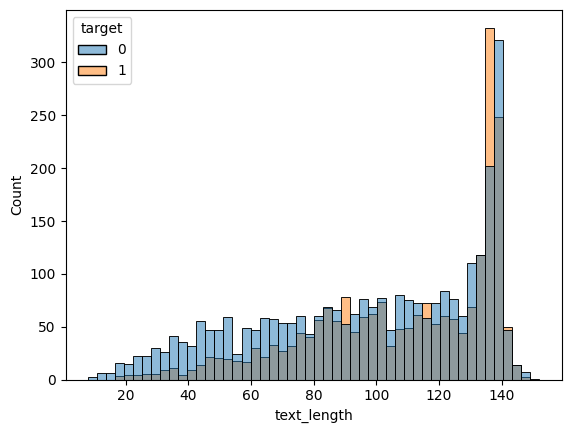

In [8]:
import seaborn as sns

sns.histplot(data=df, x='text_length', hue='target', bins=50)
plt.show()

In [9]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"%20", "", text)
    return text

df['dirty_text'] = df['text']
df['text'] = df['text'].apply(clean_text)
df['keyword'] = df['keyword'].apply(clean_text)

In [10]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered = [w for w in words if w.lower() not in stop_words]
    return " ".join(filtered)

df['text'] = df['text'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /home/ariel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5080 entries, 31 to 7581
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   keyword      5080 non-null   object
 1   location     5080 non-null   object
 2   text         5080 non-null   object
 3   target       5080 non-null   int64 
 4   text_length  5080 non-null   int64 
 5   dirty_text   5080 non-null   object
dtypes: int64(2), object(4)
memory usage: 277.8+ KB


In [12]:
df

,keyword,location,text,target,text_length,dirty_text
31,ablaze,Birmingham,bbcmtd wholesale markets ablaze,1,55,@bbcmtd Wholesale Markets ablaze http://t.co/l...
32,ablaze,Est. September 2012 - Bristol,always try bring heavy metal rt,0,67,We always try to bring the heavy. #metal #RT h...
33,ablaze,AFRICA,africanbaze breaking newsnigeria flag set abla...,1,82,#AFRICANBAZE: Breaking news:Nigeria flag set a...
34,ablaze,"Philadelphia, PA",crying set ablaze,0,34,Crying out for more! Set me ablaze
35,ablaze,"London, UK",plus side look sky last night ablaze,0,76,On plus side LOOK AT THE SKY LAST NIGHT IT WAS...
...,...,...,...,...,...,...
7575,wrecked,TN,bright side wrecked,0,51,On the bright side I wrecked http://t.co/uEa0t...
7577,wrecked,#NewcastleuponTyne #UK,widda hes gone relax thought wife wrecked cake...,0,107,@widda16 ... He's gone. You can relax. I thoug...
7579,wrecked,"Vancouver, Canada",three days work theyve pretty much wrecked hah...,0,107,Three days off from work and they've pretty mu...
7580,wrecked,London,fx forex trading cramer igers words wrecked di...,0,93,#FX #forex #trading Cramer: Iger's 3 words tha...


In [13]:
from collections import Counter

words = " ".join(df[df['target']==1]['text']).split()
Counter(words).most_common(20)

[('fire', 125),
 ('via', 87),
 ('police', 81),
 ('news', 77),
 ('amp', 75),
 ('disaster', 71),
 ('people', 68),
 ('like', 66),
 ('pm', 64),
 ('california', 63),
 ('buildings', 63),
 ('killed', 61),
 ('suicide', 61),
 ('families', 59),
 ('emergency', 58),
 ('us', 57),
 ('storm', 57),
 ('hiroshima', 57),
 ('accident', 52),
 ('burning', 52)]

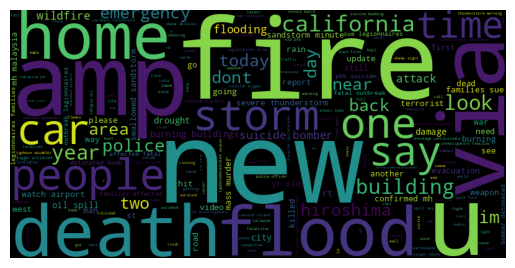

In [14]:
from wordcloud import WordCloud

text_real = " ".join(df[df['target']==1]['text'])

wordcloud = WordCloud(width=800, height=400).generate(text_real)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [15]:
df['location'].value_counts().head(20)

location
USA                104
New York            71
United States       50
London              45
Canada              29
Nigeria             28
UK                  27
Los Angeles, CA     26
India               24
Mumbai              22
Washington, DC      21
Kenya               20
Worldwide           19
Chicago, IL         18
Australia           18
California          17
New York, NY        15
California, USA     15
Everywhere          15
San Francisco       14
Name: count, dtype: int64

In [16]:
df.groupby('keyword')['target'].mean().sort_values(ascending=False).head(20)

keyword
derailment          1.000000
debris              1.000000
suicidebomber       1.000000
wreckage            1.000000
oilspill            1.000000
suicidebombing      1.000000
outbreak            0.967742
typhoon             0.960000
rescuers            0.941176
bombing             0.928571
evacuated           0.925926
suicidebomb         0.916667
massmurder          0.880000
forestfires         0.866667
nucleardisaster     0.866667
buildingsonfire     0.862069
airplaneaccident    0.827586
wildfires           0.826087
thunderstorm        0.826087
bushfires           0.823529
Name: target, dtype: float64

In [17]:
# Número total de filas
print("Total tweets:", len(df))

# Detectar duplicados exactos por texto
duplicates = df.duplicated(subset='text')

print("Número de tweets duplicados:", duplicates.sum())

Total tweets: 5080
Número de tweets duplicados: 419


In [18]:
df[df.duplicated(subset='text', keep=False)].sort_values('text').head(10)

,keyword,location,text,target,text_length,dirty_text
4290,hellfire,"Jubail IC, Saudi Arabia.",allah describes piling wealth thinking would l...,0,138,#Allah describes piling up #wealth thinking it...
4299,hellfire,?????? ??? ?????? ????????,allah describes piling wealth thinking would l...,0,138,#Allah describes piling up #wealth thinking it...
4312,hellfire,?????? ???? ??????,allah describes piling wealth thinking would l...,1,138,#Allah describes piling up #wealth thinking it...
193,ambulance,Happily Married with 2 kids,ambulance sprinter automatic frontline vehicle...,0,103,AMBULANCE SPRINTER AUTOMATIC FRONTLINE VEHICLE...
186,ambulance,Happily Married with 2 kids,ambulance sprinter automatic frontline vehicle...,0,103,AMBULANCE SPRINTER AUTOMATIC FRONTLINE VEHICLE...
178,ambulance,Happily Married with 2 kids,ambulance sprinter automatic frontline vehicle...,0,103,AMBULANCE SPRINTER AUTOMATIC FRONTLINE VEHICLE...
192,ambulance,Happily Married with 2 kids,ambulance sprinter automatic frontline vehicle...,0,103,AMBULANCE SPRINTER AUTOMATIC FRONTLINE VEHICLE...
7076,upheaval,Woosley,ancient mayan tablet hieroglyphics honors lowl...,0,80,Ancient Mayan Tablet with Hieroglyphics Honors...
7066,upheaval,NYC,ancient mayan tablet hieroglyphics honors lowl...,0,103,Ancient Mayan Tablet with Hieroglyphics Honors...
2846,displaced,Nigeria,angry woman openly accuses nema stealing relie...,0,136,Angry Woman Openly Accuses NEMA Of Stealing Re...


In [19]:
df = df.drop_duplicates(subset='text')
print("Nuevo tamaño del dataset:", len(df))

Nuevo tamaño del dataset: 4661


In [20]:
print("Tweets finales:", len(df))
df['target'].value_counts(normalize=True)

Tweets finales: 4661


target
0    0.582278
1    0.417722
Name: proportion, dtype: float64

In [21]:
df['mention_count'] = df['dirty_text'].str.count(r'@\w+')
df['hashtag_count'] = df['dirty_text'].str.count(r'#\w+')

/tmp/ipykernel_51036/100230273.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mention_count'] = df['dirty_text'].str.count(r'@\w+')
/tmp/ipykernel_51036/100230273.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hashtag_count'] = df['dirty_text'].str.count(r'#\w+')


In [22]:
df.groupby('target')['hashtag_count'].mean()

target
0    0.382830
1    0.494607
Name: hashtag_count, dtype: float64

In [23]:
df['hashtags'] = df['dirty_text'].str.findall(r'#(\w+)')
df

/tmp/ipykernel_51036/1754790793.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hashtags'] = df['dirty_text'].str.findall(r'#(\w+)')


,keyword,location,text,target,text_length,dirty_text,mention_count,hashtag_count,hashtags
31,ablaze,Birmingham,bbcmtd wholesale markets ablaze,1,55,@bbcmtd Wholesale Markets ablaze http://t.co/l...,1,0,[]
32,ablaze,Est. September 2012 - Bristol,always try bring heavy metal rt,0,67,We always try to bring the heavy. #metal #RT h...,0,2,"[metal, RT]"
33,ablaze,AFRICA,africanbaze breaking newsnigeria flag set abla...,1,82,#AFRICANBAZE: Breaking news:Nigeria flag set a...,0,1,[AFRICANBAZE]
34,ablaze,"Philadelphia, PA",crying set ablaze,0,34,Crying out for more! Set me ablaze,0,0,[]
35,ablaze,"London, UK",plus side look sky last night ablaze,0,76,On plus side LOOK AT THE SKY LAST NIGHT IT WAS...,0,0,[]
...,...,...,...,...,...,...,...,...,...
7575,wrecked,TN,bright side wrecked,0,51,On the bright side I wrecked http://t.co/uEa0t...,0,0,[]
7577,wrecked,#NewcastleuponTyne #UK,widda hes gone relax thought wife wrecked cake...,0,107,@widda16 ... He's gone. You can relax. I thoug...,1,1,[whoops]
7579,wrecked,"Vancouver, Canada",three days work theyve pretty much wrecked hah...,0,107,Three days off from work and they've pretty mu...,0,0,[]
7580,wrecked,London,fx forex trading cramer igers words wrecked di...,0,93,#FX #forex #trading Cramer: Iger's 3 words tha...,0,3,"[FX, forex, trading]"


In [24]:
from itertools import chain
from collections import Counter

all_hashtags = list(chain.from_iterable(df['hashtags']))

hashtag_counts = Counter(all_hashtags)

hashtag_counts.most_common(20)

[('News', 22),
 ('news', 17),
 ('GBBO', 16),
 ('NowPlaying', 12),
 ('Hiroshima', 12),
 ('yyc', 9),
 ('nowplaying', 8),
 ('jobs', 8),
 ('abstorm', 7),
 ('Nursing', 7),
 ('WX', 7),
 ('hiring', 6),
 ('Job', 6),
 ('job', 6),
 ('okwx', 6),
 ('MTVHottest', 5),
 ('Seattle', 5),
 ('tcot', 5),
 ('MH370', 5),
 ('India', 5)]

In [25]:
real_hashtags = list(chain.from_iterable(
    df[df['target']==1]['hashtags']
))

fake_hashtags = list(chain.from_iterable(
    df[df['target']==0]['hashtags']
))

print("Hashtags más comunes en tweets relacionados con desastres:")
print(Counter(real_hashtags).most_common(15))
print("\nHashtags más comunes en tweets no relacionados con desastres:")
print(Counter(fake_hashtags).most_common(15))

Hashtags más comunes en tweets relacionados con desastres:
[('News', 21), ('Hiroshima', 12), ('news', 9), ('yyc', 9), ('abstorm', 7), ('WX', 7), ('okwx', 6), ('MH370', 5), ('India', 5), ('earthquake', 5), ('Manchester', 4), ('wildfire', 4), ('disaster', 4), ('drought', 4), ('Earthquake', 4)]

Hashtags más comunes en tweets no relacionados con desastres:
[('GBBO', 12), ('NowPlaying', 10), ('news', 8), ('nowplaying', 8), ('jobs', 8), ('hiring', 6), ('Job', 6), ('job', 6), ('Nursing', 6), ('MTVHottest', 5), ('Jobs', 5), ('IranDeal', 4), ('Seattle', 4), ('technology', 4), ('Emmerdale', 4)]


In [26]:
pd.crosstab(
    df['hashtag_count'] > 0,
    df['target'],
    normalize='columns'
)

target,0,1
hashtag_count,,
False,0.781503,0.720082
True,0.218497,0.279918


In [27]:
df

,keyword,location,text,target,text_length,dirty_text,mention_count,hashtag_count,hashtags
31,ablaze,Birmingham,bbcmtd wholesale markets ablaze,1,55,@bbcmtd Wholesale Markets ablaze http://t.co/l...,1,0,[]
32,ablaze,Est. September 2012 - Bristol,always try bring heavy metal rt,0,67,We always try to bring the heavy. #metal #RT h...,0,2,"[metal, RT]"
33,ablaze,AFRICA,africanbaze breaking newsnigeria flag set abla...,1,82,#AFRICANBAZE: Breaking news:Nigeria flag set a...,0,1,[AFRICANBAZE]
34,ablaze,"Philadelphia, PA",crying set ablaze,0,34,Crying out for more! Set me ablaze,0,0,[]
35,ablaze,"London, UK",plus side look sky last night ablaze,0,76,On plus side LOOK AT THE SKY LAST NIGHT IT WAS...,0,0,[]
...,...,...,...,...,...,...,...,...,...
7575,wrecked,TN,bright side wrecked,0,51,On the bright side I wrecked http://t.co/uEa0t...,0,0,[]
7577,wrecked,#NewcastleuponTyne #UK,widda hes gone relax thought wife wrecked cake...,0,107,@widda16 ... He's gone. You can relax. I thoug...,1,1,[whoops]
7579,wrecked,"Vancouver, Canada",three days work theyve pretty much wrecked hah...,0,107,Three days off from work and they've pretty mu...,0,0,[]
7580,wrecked,London,fx forex trading cramer igers words wrecked di...,0,93,#FX #forex #trading Cramer: Iger's 3 words tha...,0,3,"[FX, forex, trading]"


In [28]:
from collections import Counter
from itertools import chain

all_hashtags = list(chain.from_iterable(df['hashtags']))
top_hashtags = [h for h, _ in Counter(all_hashtags).most_common(30)]

for tag in top_hashtags:
    df[f"hashtag_{tag}"] = df['hashtags'].apply(lambda x: int(tag in x))

/tmp/ipykernel_51036/1012233445.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"hashtag_{tag}"] = df['hashtags'].apply(lambda x: int(tag in x))
/tmp/ipykernel_51036/1012233445.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"hashtag_{tag}"] = df['hashtags'].apply(lambda x: int(tag in x))
/tmp/ipykernel_51036/1012233445.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in 

In [29]:
df.drop(columns=['hashtags'], inplace=True)

/tmp/ipykernel_51036/1834005072.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['hashtags'], inplace=True)


In [30]:
df

,keyword,location,text,target,text_length,dirty_text,mention_count,hashtag_count,hashtag_News,hashtag_news,...,hashtag_drought,hashtag_Sismo,hashtag_earthquake,hashtag_Jobs,hashtag_islam,hashtag_art,hashtag_PantherAttack,hashtag_KerrickTrial,hashtag_Manchester,hashtag_PBBan
31,ablaze,Birmingham,bbcmtd wholesale markets ablaze,1,55,@bbcmtd Wholesale Markets ablaze http://t.co/l...,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
32,ablaze,Est. September 2012 - Bristol,always try bring heavy metal rt,0,67,We always try to bring the heavy. #metal #RT h...,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
33,ablaze,AFRICA,africanbaze breaking newsnigeria flag set abla...,1,82,#AFRICANBAZE: Breaking news:Nigeria flag set a...,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
34,ablaze,"Philadelphia, PA",crying set ablaze,0,34,Crying out for more! Set me ablaze,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
35,ablaze,"London, UK",plus side look sky last night ablaze,0,76,On plus side LOOK AT THE SKY LAST NIGHT IT WAS...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7575,wrecked,TN,bright side wrecked,0,51,On the bright side I wrecked http://t.co/uEa0t...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7577,wrecked,#NewcastleuponTyne #UK,widda hes gone relax thought wife wrecked cake...,0,107,@widda16 ... He's gone. You can relax. I thoug...,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
7579,wrecked,"Vancouver, Canada",three days work theyve pretty much wrecked hah...,0,107,Three days off from work and they've pretty mu...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7580,wrecked,London,fx forex trading cramer igers words wrecked di...,0,93,#FX #forex #trading Cramer: Iger's 3 words tha...,0,3,0,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
from scipy.stats import chi2_contingency

results = []

for tag in top_hashtags:
    col = f"hashtag_{tag}"
    
    contingency = pd.crosstab(df[col], df['target'])
    chi2, p, _, _ = chi2_contingency(contingency)
    
    results.append((tag, p))

results_df = pd.DataFrame(results, columns=["hashtag", "p_value"])
results_df.sort_values("p_value").head(10)

,hashtag,p_value
0,News,9.540489e-07
4,Hiroshima,1.434565e-04
5,yyc,1.340739e-03
8,abstorm,6.095789e-03
10,WX,6.095789e-03
14,okwx,1.314925e-02
18,MH370,2.868434e-02
19,India,2.868434e-02
22,earthquake,2.868434e-02
7,jobs,4.145412e-02


In [32]:
from sklearn.feature_selection import mutual_info_classif

X = df[[f"hashtag_{tag}" for tag in top_hashtags]]
y = df['target']

mi = mutual_info_classif(X, y, discrete_features=True)

mi_df = pd.DataFrame({
    "hashtag": top_hashtags,
    "mutual_info": mi
}).sort_values("mutual_info", ascending=False)

mi_df.head(10)

,hashtag,mutual_info
0,News,0.003190
4,Hiroshima,0.002252
5,yyc,0.001688
8,abstorm,0.001313
10,WX,0.001313
14,okwx,0.001125
22,earthquake,0.000937
19,India,0.000937
18,MH370,0.000937
7,jobs,0.000929


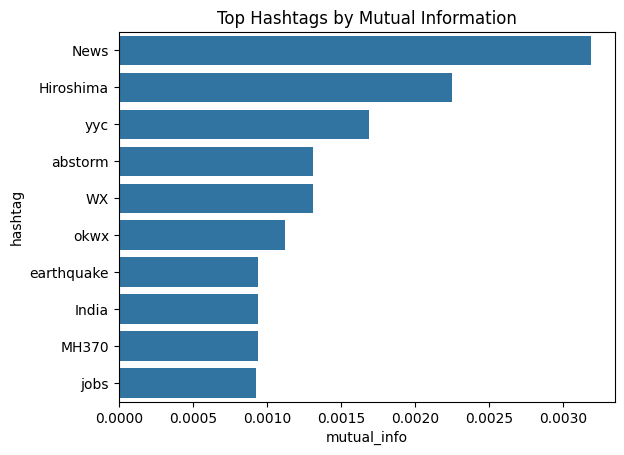

In [33]:
sns.barplot(
    x="mutual_info",
    y="hashtag",
    data=mi_df.head(10)
)
plt.title("Top Hashtags by Mutual Information")
plt.show()

In [34]:
df['dirty_text']

31      @bbcmtd Wholesale Markets ablaze http://t.co/l...
32      We always try to bring the heavy. #metal #RT h...
33      #AFRICANBAZE: Breaking news:Nigeria flag set a...
34                     Crying out for more! Set me ablaze
35      On plus side LOOK AT THE SKY LAST NIGHT IT WAS...
                              ...                        
7575    On the bright side I wrecked http://t.co/uEa0t...
7577    @widda16 ... He's gone. You can relax. I thoug...
7579    Three days off from work and they've pretty mu...
7580    #FX #forex #trading Cramer: Iger's 3 words tha...
7581    @engineshed Great atmosphere at the British Li...
Name: dirty_text, Length: 4661, dtype: object

In [35]:
import re

emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FAFF"
    "\U00002700-\U000027BF"
    "]+",
    flags=re.UNICODE
)

df['has_emoji'] = df['dirty_text'].apply(lambda x: bool(emoji_pattern.search(str(x))))
df.groupby('target')['has_emoji'].mean()

/tmp/ipykernel_51036/1724319189.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['has_emoji'] = df['dirty_text'].apply(lambda x: bool(emoji_pattern.search(str(x))))


target
0    0.0
1    0.0
Name: has_emoji, dtype: float64

In [36]:
df.drop(columns=['has_emoji'], inplace=True)

/tmp/ipykernel_51036/217100616.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['has_emoji'], inplace=True)


In [37]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

def plot_top_ngrams_by_class(df, text_col, target_col, ngram_range=(1,1), top_n=20):
    
    for label in df[target_col].unique():
        
        subset = df[df[target_col] == label]
        
        vectorizer = CountVectorizer(
            ngram_range=ngram_range,
            stop_words='english',
            min_df=2
        )
        
        X = vectorizer.fit_transform(subset[text_col])
        
        # Sum of each ngram
        counts = X.sum(axis=0)
        ngrams = vectorizer.get_feature_names_out()
        
        ngram_freq = [
            (ngrams[i], counts[0, i]) 
            for i in range(len(ngrams))
        ]
        
        # Sort
        ngram_freq = sorted(ngram_freq, key=lambda x: x[1], reverse=True)[:top_n]
        
        words = [x[0] for x in ngram_freq]
        values = [x[1] for x in ngram_freq]
        
        # Plot
        plt.figure()
        plt.barh(words[::-1], values[::-1])
        plt.title(f"Top {top_n} ngrams {ngram_range} - Class {label}")
        plt.xlabel("Frequency")
        plt.show()

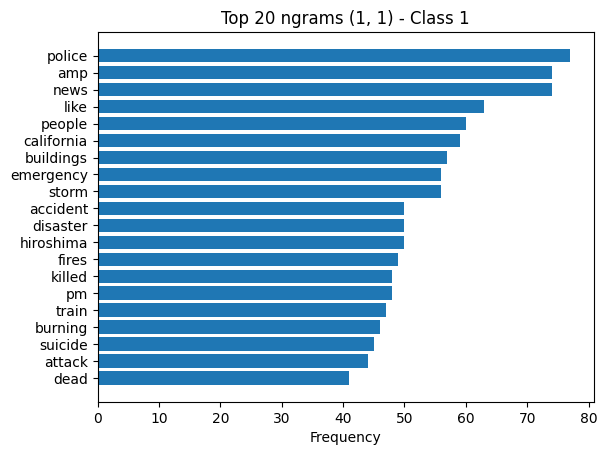

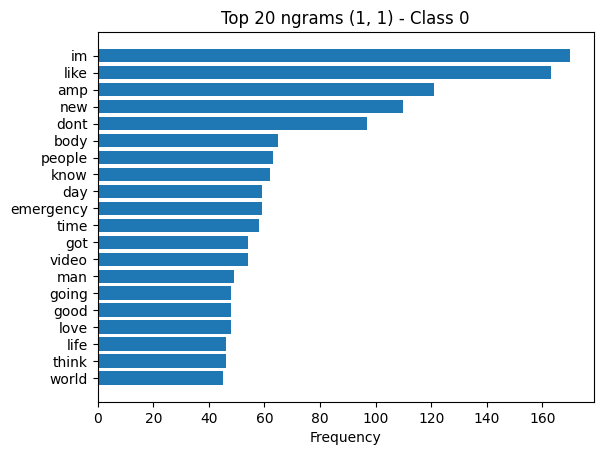

In [38]:
plot_top_ngrams_by_class(df, 'text', 'target', ngram_range=(1,1), top_n=20)

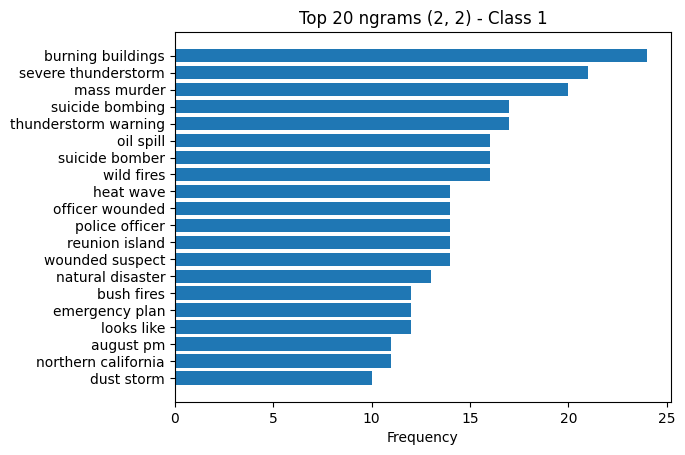

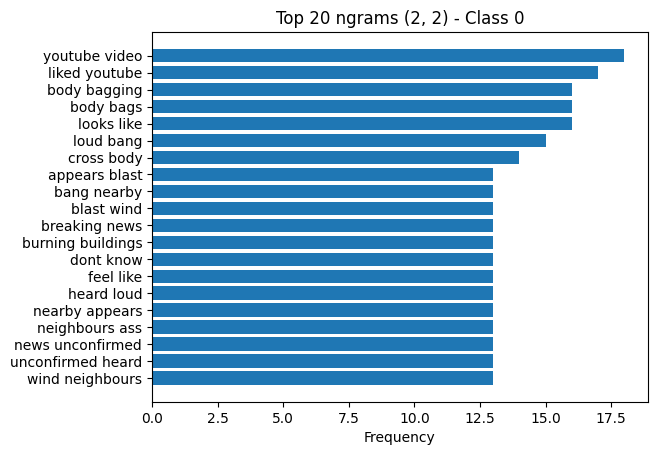

In [39]:
plot_top_ngrams_by_class(df, 'text', 'target', ngram_range=(2,2), top_n=20)

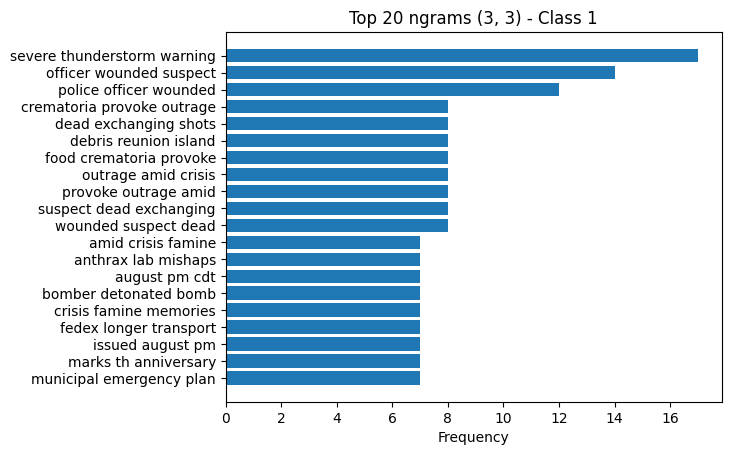

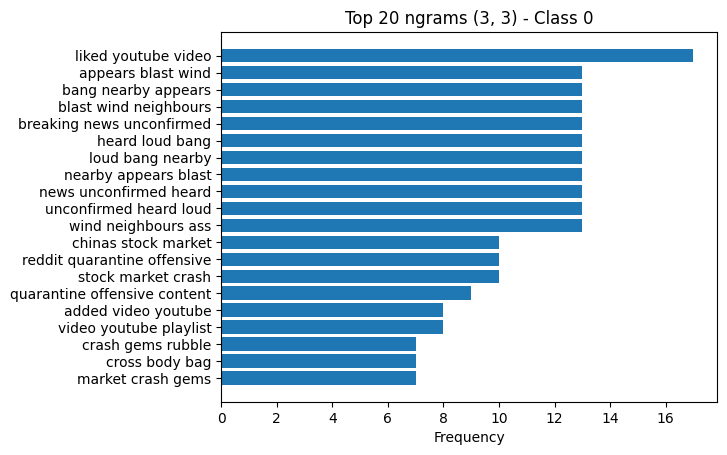

In [40]:
plot_top_ngrams_by_class(df, 'text', 'target', ngram_range=(3,3), top_n=20)

In [41]:
df['exclamation_count'] = df['dirty_text'].str.count('!')
df['question_count'] = df['dirty_text'].str.count(r'\?')
df['uppercase_ratio'] = df['dirty_text'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0
)

/tmp/ipykernel_51036/576284057.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['exclamation_count'] = df['dirty_text'].str.count('!')
/tmp/ipykernel_51036/576284057.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['question_count'] = df['dirty_text'].str.count(r'\?')
/tmp/ipykernel_51036/576284057.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

In [42]:
import string

df['punctuation_count'] = df['dirty_text'].apply(
    lambda x: sum(1 for c in x if c in string.punctuation)
)

/tmp/ipykernel_51036/2174467601.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['punctuation_count'] = df['dirty_text'].apply(


In [43]:
df['all_caps_word_count'] = df['dirty_text'].apply(
    lambda x: sum(1 for word in x.split() if word.isupper() and len(word) > 2)
)

/tmp/ipykernel_51036/812011024.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['all_caps_word_count'] = df['dirty_text'].apply(


In [44]:
df[['dirty_text',
    'exclamation_count',
    'question_count',
    'uppercase_ratio',
    'punctuation_count',
    'all_caps_word_count']].head()

,dirty_text,exclamation_count,question_count,uppercase_ratio,punctuation_count,all_caps_word_count
31,@bbcmtd Wholesale Markets ablaze http://t.co/l...,0,0,0.181818,6,0
32,We always try to bring the heavy. #metal #RT h...,0,0,0.074627,8,1
33,#AFRICANBAZE: Breaking news:Nigeria flag set a...,0,0,0.207317,9,1
34,Crying out for more! Set me ablaze,1,0,0.058824,1,0
35,On plus side LOOK AT THE SKY LAST NIGHT IT WAS...,0,0,0.460526,5,7


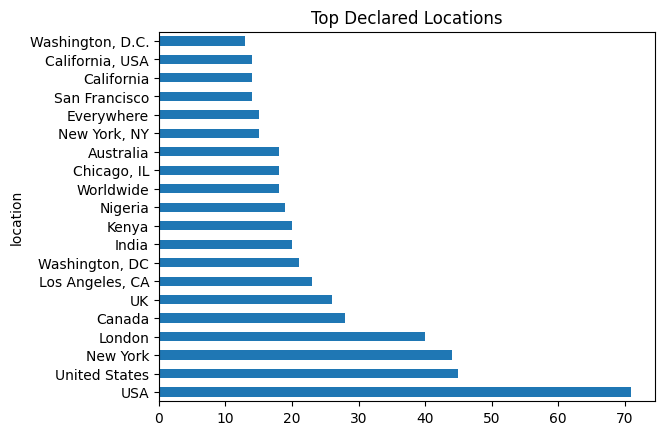

In [45]:
df['location'].value_counts().head(20).plot(kind='barh')
plt.title("Top Declared Locations")
plt.show()

In [46]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df['sentiment_scores'] = df['dirty_text'].apply(lambda x: sia.polarity_scores(x))

df['sentiment_compound'] = df['sentiment_scores'].apply(lambda x: x['compound'])
df['sentiment_positive'] = df['sentiment_scores'].apply(lambda x: x['pos'])
df['sentiment_negative'] = df['sentiment_scores'].apply(lambda x: x['neg'])
df['sentiment_neutral'] = df['sentiment_scores'].apply(lambda x: x['neu'])

df.groupby('target')['sentiment_compound'].mean()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/ariel/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
/tmp/ipykernel_51036/740152350.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment_scores'] = df['dirty_text'].apply(lambda x: sia.polarity_scores(x))
/tmp/ipykernel_51036/740152350.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment_compound'] = df['sentiment_scores'].apply(lambda x: x['compound'])
/tmp/ipykernel_51036/740152350.py:

target
0   -0.065314
1   -0.254640
Name: sentiment_compound, dtype: float64

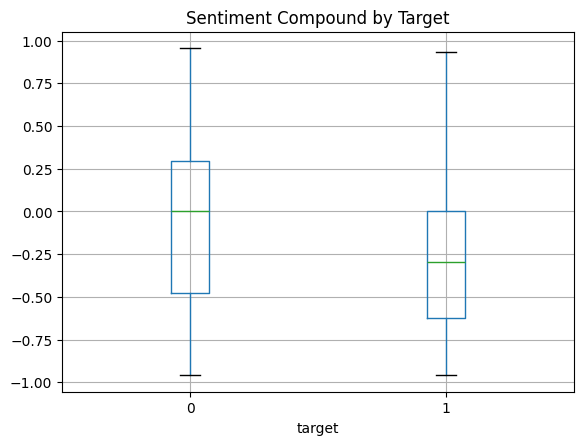

In [47]:
import matplotlib.pyplot as plt

df.boxplot(column='sentiment_compound', by='target')
plt.title("Sentiment Compound by Target")
plt.suptitle("")
plt.show()

In [48]:
fear_words = ['fear', 'terrified', 'scared', 'panic', 'afraid']
anger_words = ['angry', 'rage', 'furious', 'mad']
sadness_words = ['sad', 'cry', 'tears', 'depressed']
urgency_words = ['help', 'urgent', 'emergency', 'now', 'immediately']

def count_emotion_words(text, word_list):
    words = text.lower().split()
    return sum(1 for w in words if w in word_list)

df['fear_count'] = df['dirty_text'].apply(lambda x: count_emotion_words(x, fear_words))
df['anger_count'] = df['dirty_text'].apply(lambda x: count_emotion_words(x, anger_words))
df['sadness_count'] = df['dirty_text'].apply(lambda x: count_emotion_words(x, sadness_words))
df['urgency_count'] = df['dirty_text'].apply(lambda x: count_emotion_words(x, urgency_words))

df.groupby('target')[['fear_count','anger_count','sadness_count','urgency_count']].mean()

/tmp/ipykernel_51036/3913439958.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['fear_count'] = df['dirty_text'].apply(lambda x: count_emotion_words(x, fear_words))
/tmp/ipykernel_51036/3913439958.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['anger_count'] = df['dirty_text'].apply(lambda x: count_emotion_words(x, anger_words))
/tmp/ipykernel_51036/3913439958.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_in

,fear_count,anger_count,sadness_count,urgency_count
target,,,,
0,0.021739,0.006264,0.003316,0.060427
1,0.005650,0.003082,0.003595,0.053929


In [49]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Modelo ligero y bueno
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generar embeddings
embeddings = model.encode(
    df['dirty_text'].tolist(),
    show_progress_bar=True
)

embeddings = np.array(embeddings)

print(embeddings.shape)  # (n_samples, 384)

/home/ariel/Escritorio/proyectos/nlp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1632.82it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 146/146 [00:58<00:00,  2.49it/s]

(4661, 384)


In [50]:
import umap

reducer = umap.UMAP(
    n_components=2,
    random_state=42
)

embedding_2d = reducer.fit_transform(embeddings)

/home/ariel/Escritorio/proyectos/nlp/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


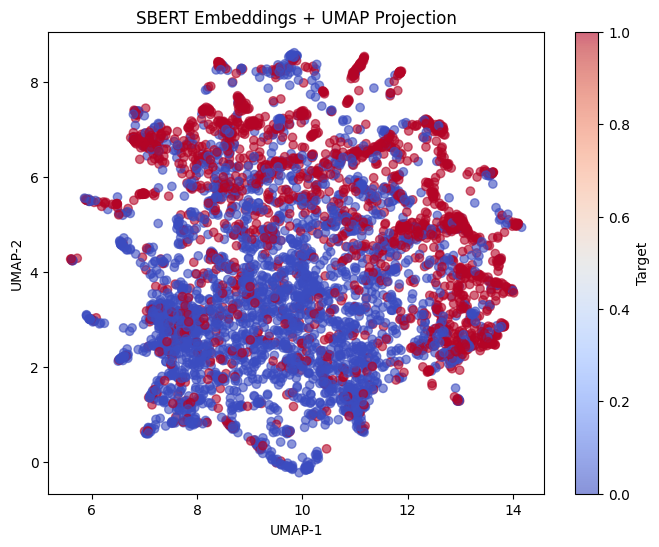

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=df['target'],
    cmap='coolwarm',
    alpha=0.6
)

plt.colorbar(label='Target')
plt.title("SBERT Embeddings + UMAP Projection")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

In [52]:
import umap

reducer_cluster = umap.UMAP(
    n_components=15,
    random_state=42
)

embeddings_reduced = reducer_cluster.fit_transform(embeddings)

/home/ariel/Escritorio/proyectos/nlp/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [53]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,   # ajustable
    min_samples=10,        # controla sensibilidad
    metric='euclidean'
)

clusters = clusterer.fit_predict(embeddings_reduced)

df['cluster'] = clusters

/tmp/ipykernel_51036/1532226286.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster'] = clusters


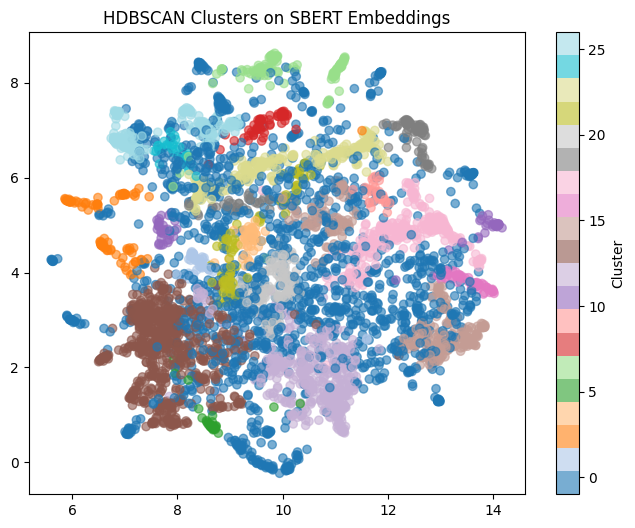

In [54]:
plt.figure(figsize=(8,6))

plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=df['cluster'],
    cmap='tab20',
    alpha=0.6
)

plt.colorbar(label='Cluster')
plt.title("HDBSCAN Clusters on SBERT Embeddings")
plt.show()

In [55]:
import pandas as pd

pd.crosstab(df['cluster'], df['target'])

target,0,1
cluster,,
-1,932,574
0,67,9
1,34,11
2,12,45
3,41,6
4,33,13
5,25,12
6,1,48
7,55,22


In [56]:
from sklearn.metrics import silhouette_score
import numpy as np

mask = clusters != -1

sil_score = silhouette_score(
    embeddings_reduced[mask],
    clusters[mask]
)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.43678364157676697


In [57]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),     # unigrams + bigrams
    stop_words='english',
    max_features=500,
    min_df=2
)

X_tfidf = vectorizer.fit_transform(df['text'])

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=df.index
)

df_final = pd.concat([df, tfidf_df], axis=1)

tfidf_df.head()

,ablaze,accident,actually,ago,air,airplane,ambulance,american,amp,annihilated,...,wreck,wrecked,yeah,year,years,yes,youre,youtube,youtube video,zone
31,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33,0.604552,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34,0.735766,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
35,0.606051,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [58]:
tfidf_df['target'] = df['target']
correlations = tfidf_df.corr()['target'].drop('target')
top_positive = correlations.sort_values(ascending=False).head(15)
top_negative = correlations.sort_values().head(15)

selected_features = list(top_positive.index) + list(top_negative.index)
corr_subset = tfidf_df[selected_features + ['target']].corr()

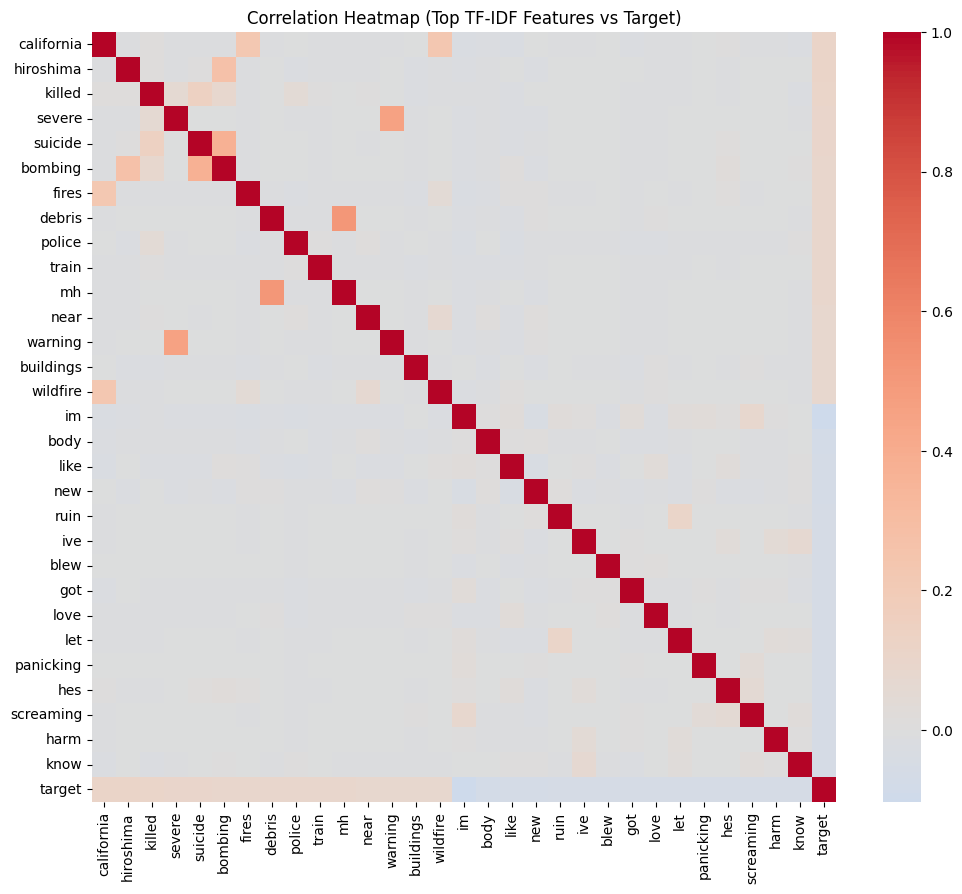

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(
    corr_subset,
    cmap='coolwarm',
    center=0,
    annot=False
)

plt.title("Correlation Heatmap (Top TF-IDF Features vs Target)")
plt.show()

In [60]:
df

,keyword,location,text,target,text_length,dirty_text,mention_count,hashtag_count,hashtag_News,hashtag_news,...,sentiment_scores,sentiment_compound,sentiment_positive,sentiment_negative,sentiment_neutral,fear_count,anger_count,sadness_count,urgency_count,cluster
31,ablaze,Birmingham,bbcmtd wholesale markets ablaze,1,55,@bbcmtd Wholesale Markets ablaze http://t.co/l...,1,0,0,0,...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,0,0,0,0,-1
32,ablaze,Est. September 2012 - Bristol,always try bring heavy metal rt,0,67,We always try to bring the heavy. #metal #RT h...,0,2,0,0,...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,0,0,0,0,12
33,ablaze,AFRICA,africanbaze breaking newsnigeria flag set abla...,1,82,#AFRICANBAZE: Breaking news:Nigeria flag set a...,0,1,0,0,...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,0,0,0,0,8
34,ablaze,"Philadelphia, PA",crying set ablaze,0,34,Crying out for more! Set me ablaze,0,0,0,0,...,"{'neg': 0.361, 'neu': 0.639, 'pos': 0.0, 'comp...",-0.5255,0.000,0.361,0.639,0,0,0,0,17
35,ablaze,"London, UK",plus side look sky last night ablaze,0,76,On plus side LOOK AT THE SKY LAST NIGHT IT WAS...,0,0,0,0,...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,0,0,0,0,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7575,wrecked,TN,bright side wrecked,0,51,On the bright side I wrecked http://t.co/uEa0t...,0,0,0,0,...,"{'neg': 0.0, 'neu': 0.633, 'pos': 0.367, 'comp...",0.4404,0.367,0.000,0.633,0,0,0,0,-1
7577,wrecked,#NewcastleuponTyne #UK,widda hes gone relax thought wife wrecked cake...,0,107,@widda16 ... He's gone. You can relax. I thoug...,1,1,0,0,...,"{'neg': 0.0, 'neu': 0.749, 'pos': 0.251, 'comp...",0.6908,0.251,0.000,0.749,0,0,0,0,13
7579,wrecked,"Vancouver, Canada",three days work theyve pretty much wrecked hah...,0,107,Three days off from work and they've pretty mu...,0,0,0,0,...,"{'neg': 0.0, 'neu': 0.726, 'pos': 0.274, 'comp...",0.7783,0.274,0.000,0.726,0,0,0,0,-1
7580,wrecked,London,fx forex trading cramer igers words wrecked di...,0,93,#FX #forex #trading Cramer: Iger's 3 words tha...,0,3,0,0,...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,0,0,0,0,7


In [61]:
df['location'].value_counts().head(20)

top_locations = df['location'].value_counts().head(15).index

df_top = df[df['location'].isin(top_locations)]

location_target = (
    df_top
    .groupby(['location', 'target'])
    .size()
    .unstack(fill_value=0)
)

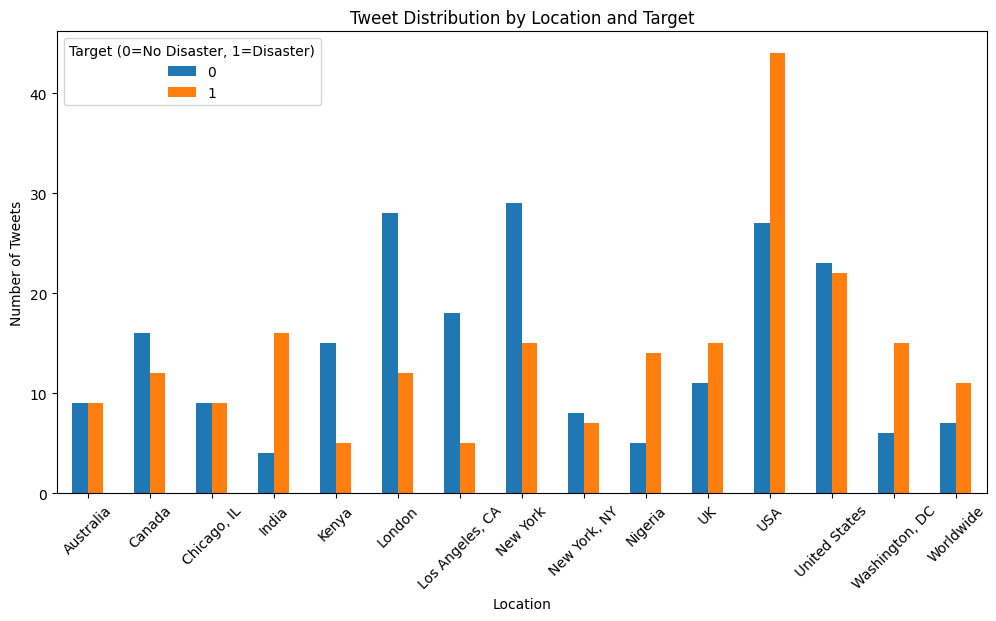

In [62]:
import matplotlib.pyplot as plt

location_target.plot(kind='bar', figsize=(12,6))

plt.title("Tweet Distribution by Location and Target")
plt.xlabel("Location")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.legend(title="Target (0=No Disaster, 1=Disaster)")
plt.show()

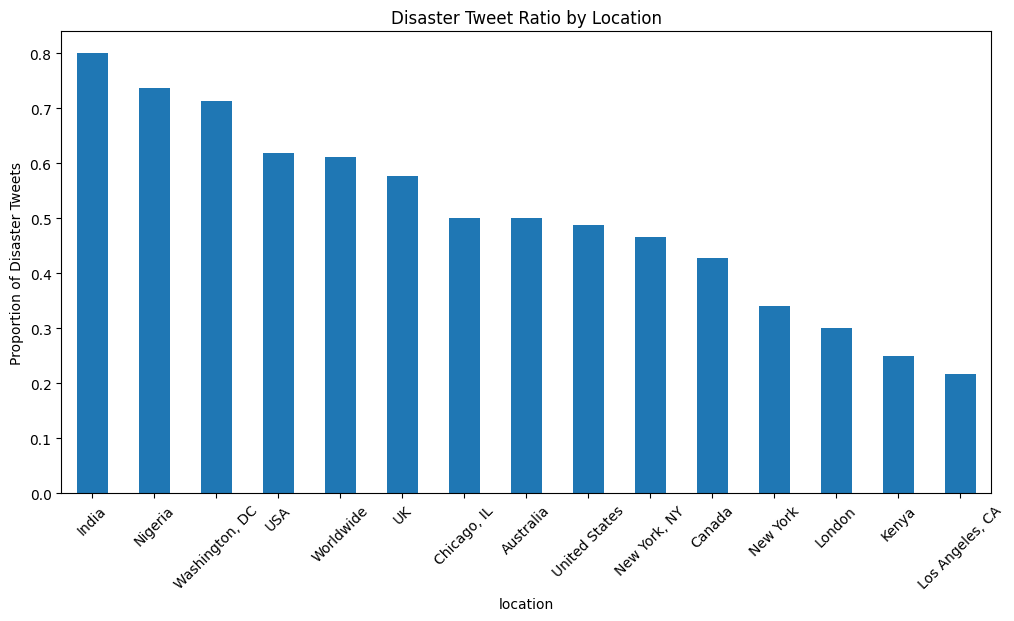

In [63]:
location_target['disaster_ratio'] = (
    location_target[1] /
    (location_target[0] + location_target[1])
)

location_target.sort_values('disaster_ratio', ascending=False)['disaster_ratio'].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Disaster Tweet Ratio by Location")
plt.ylabel("Proportion of Disaster Tweets")
plt.xticks(rotation=45)
plt.show()

In [64]:
df.drop(columns=['dirty_text'], inplace=True)

/tmp/ipykernel_51036/815245863.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['dirty_text'], inplace=True)


In [65]:
df.drop(columns=['sentiment_scores'], inplace=True)

/tmp/ipykernel_51036/758761803.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['sentiment_scores'], inplace=True)


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4661 entries, 31 to 7581
Data columns (total 51 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   keyword                4661 non-null   object 
 1   location               4661 non-null   object 
 2   text                   4661 non-null   object 
 3   target                 4661 non-null   int64  
 4   text_length            4661 non-null   int64  
 5   mention_count          4661 non-null   int64  
 6   hashtag_count          4661 non-null   int64  
 7   hashtag_News           4661 non-null   int64  
 8   hashtag_news           4661 non-null   int64  
 9   hashtag_GBBO           4661 non-null   int64  
 10  hashtag_NowPlaying     4661 non-null   int64  
 11  hashtag_Hiroshima      4661 non-null   int64  
 12  hashtag_yyc            4661 non-null   int64  
 13  hashtag_nowplaying     4661 non-null   int64  
 14  hashtag_jobs           4661 non-null   int64  
 15  hashtag_

In [67]:
from sklearn.preprocessing import StandardScaler

extra_features = [
    'text_length','mention_count','hashtag_count',
    'exclamation_count','question_count','uppercase_ratio',
    'punctuation_count','all_caps_word_count',
    'sentiment_compound','sentiment_positive',
    'sentiment_negative','sentiment_neutral',
    'fear_count','anger_count','sadness_count','urgency_count'
]

scaler = StandardScaler()

X_extra = scaler.fit_transform(df[extra_features])

In [68]:

from sklearn.model_selection import train_test_split
from scipy.sparse import hstack

X_combined = hstack([X_tfidf, X_extra])
X = X_tfidf
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # importante para balancear clases
)

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report


X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['text'],
    df['target'],
    test_size=0.2,
    random_state=42,
    stratify=df['target']
)

model = LinearSVC(C=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.83      0.80       543
           1       0.73      0.64      0.68       390

    accuracy                           0.75       933
   macro avg       0.75      0.74      0.74       933
weighted avg       0.75      0.75      0.75       933



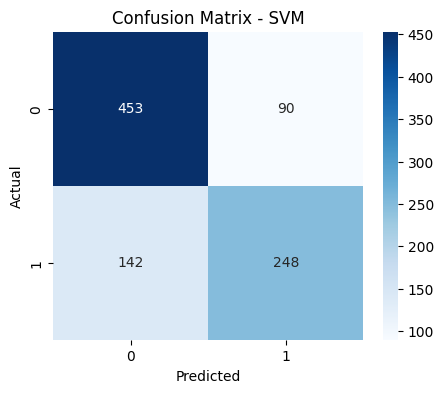

In [70]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

In [71]:
import random
import string

def add_noise(text, noise_level=0.05):
    chars = list(text)
    for i in range(len(chars)):
        if random.random() < noise_level:
            chars[i] = random.choice(string.ascii_letters)
    return "".join(chars)

In [72]:
def add_typos(text, typo_prob=0.1):
    words = text.split()
    new_words = []
    
    for word in words:
        if random.random() < typo_prob and len(word) > 3:
            i = random.randint(0, len(word)-2)
            word = word[:i] + word[i+1] + word[i] + word[i+2:]
        new_words.append(word)
    
    return " ".join(new_words)

In [73]:
translation_dict = {
    "earthquake": "terremoto",
    "fire": "incendio",
    "flood": "inundación",
    "help": "ayuda",
    "storm": "tormenta"
}

def add_code_switch(text):
    words = text.split()
    return " ".join([translation_dict.get(w.lower(), w) for w in words])

In [74]:
X_test_noise = X_test_text.apply(add_noise)
X_test_typos = X_test_text.apply(add_typos)
X_test_codeswitch = X_test_text.apply(add_code_switch)

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from scipy.sparse import hstack

# 1️⃣ Split primero (con texto crudo)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['text'],
    df['target'],
    test_size=0.2,
    random_state=42,
    stratify=df['target']
)

# 2️⃣ TF-IDF (fit SOLO en train)
vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    stop_words='english',
    max_features=500,
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

# 3️⃣ Extra features (separadas por índice)
extra_features = [
    'text_length','mention_count','hashtag_count',
    'exclamation_count','question_count','uppercase_ratio',
    'punctuation_count','all_caps_word_count',
    'sentiment_compound','sentiment_positive',
    'sentiment_negative','sentiment_neutral',
    'fear_count','anger_count','sadness_count','urgency_count'
]

scaler = StandardScaler()

X_train_extra = scaler.fit_transform(df.loc[X_train_text.index, extra_features])
X_test_extra = scaler.transform(df.loc[X_test_text.index, extra_features])

# 4️⃣ Combinar correctamente
X_train = hstack([X_train_tfidf, X_train_extra])
X_test = hstack([X_test_tfidf, X_test_extra])

# 5️⃣ Entrenar modelo
model = LinearSVC()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [76]:
from scipy.sparse import hstack

# ---- TYPOS ----
X_test_typos_vec = vectorizer.transform(X_test_typos)
X_test_typos_extra = scaler.transform(
    df.loc[X_test_text.index, extra_features]
)
X_test_typos_final = hstack([X_test_typos_vec, X_test_typos_extra])

# ---- CODE-SWITCH ----
X_test_codeswitch_vec = vectorizer.transform(X_test_codeswitch)
X_test_codeswitch_extra = scaler.transform(
    df.loc[X_test_text.index, extra_features]
)
X_test_codeswitch_final = hstack([X_test_codeswitch_vec, X_test_codeswitch_extra])

In [78]:
X_test_noise_vec = vectorizer.transform(X_test_noise)
X_test_noise_vec = vectorizer.transform(X_test_noise)
X_test_noise_extra = scaler.transform(
    df.loc[X_test_text.index, extra_features]
)

X_test_noise_final = hstack([
    X_test_noise_vec,
    X_test_noise_extra
])

In [79]:
from sklearn.metrics import accuracy_score

def evaluate(X, name):
    y_pred = model.predict(X)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy:", acc)
    return acc

acc_original = evaluate(X_test, "Original")
acc_noise = evaluate(X_test_noise_final, "Noise")
acc_typos = evaluate(X_test_typos_final, "Typos")
acc_codeswitch = evaluate(X_test_codeswitch_final, "Code-switch")

Original Accuracy: 0.7438370846730975
Noise Accuracy: 0.722400857449089
Typos Accuracy: 0.7481243301178992
Code-switch Accuracy: 0.744908896034298


In [80]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")
joblib.dump(scaler, "scaler.pkl")

data_bundle = {
    "X_test": X_test,
    "y_test": y_test,
    "X_test_noise": X_test_noise_final,
    "X_test_typos": X_test_typos_final,
    "X_test_codeswitch": X_test_codeswitch_final
}

joblib.dump(data_bundle, "data_bundle.pkl")

['data_bundle.pkl']

In [82]:
df.to_csv("dataset/tweetsDisaster/train_clean.csv", index=False)